# Principal Component Analysis with Cancer Data

In [1]:
#Import all the necessary modules
#Import all the necessary modules
import pandas as pd
import numpy as np
import os
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

# Q1. Load the Data file into Python DataFrame and view top 10 rows

In [2]:
df = pd.read_csv("cancer.csv")
df.head(10)

,ID,ClumpThickness,Cell Size,Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Normal Nucleoli,Bland Chromatin,Mitoses,Class
0,1000025,5,1,1,1,2,1,3,1,1,2
1,1002945,5,4,4,5,7,10,3,2,1,2
2,1015425,3,1,1,1,2,2,3,1,1,2
3,1016277,6,8,8,1,3,4,3,7,1,2
4,1017023,4,1,1,3,2,1,3,1,1,2
5,1017122,8,10,10,8,7,10,9,7,1,4
6,1018099,1,1,1,1,2,10,3,1,1,2
7,1018561,2,1,2,1,2,1,3,1,1,2
8,1033078,2,1,1,1,2,1,1,1,5,2
9,1033078,4,2,1,1,2,1,2,1,1,2


In [3]:
  # Id columns is to identify rows hence can be skipped in analysis
  # All columns have numerical values
  # Class would be the target variable. Should be removed when PCA is done
new_dataset = df.drop(['ID'], axis=1) # remoced the column "ID"
new_dataset.head(10)
new_dataset.info()  #Bare Nucleoli  is object converting to Int



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 699 entries, 0 to 698
Data columns (total 10 columns):
ClumpThickness                 699 non-null int64
Cell Size                      699 non-null int64
Cell Shape                     699 non-null int64
Marginal Adhesion              699 non-null int64
Single Epithelial Cell Size    699 non-null int64
Bare Nuclei                    699 non-null object
Normal Nucleoli                699 non-null int64
Bland Chromatin                699 non-null int64
Mitoses                        699 non-null int64
Class                          699 non-null int64
dtypes: int64(9), object(1)
memory usage: 54.7+ KB


# Q2 Print the datatypes of each column and the shape of the dataset. Perform descriptive analysis 

In [4]:
new_dataset.describe()

,ClumpThickness,Cell Size,Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Normal Nucleoli,Bland Chromatin,Mitoses,Class
count,699.000000,699.000000,699.000000,699.000000,699.000000,699.000000,699.000000,699.000000,699.000000
mean,4.417740,3.134478,3.207439,2.806867,3.216023,3.437768,2.866953,1.589413,2.689557
std,2.815741,3.051459,2.971913,2.855379,2.214300,2.438364,3.053634,1.715078,0.951273
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000
25%,2.000000,1.000000,1.000000,1.000000,2.000000,2.000000,1.000000,1.000000,2.000000
50%,4.000000,1.000000,1.000000,1.000000,2.000000,3.000000,1.000000,1.000000,2.000000
75%,6.000000,5.000000,5.000000,4.000000,4.000000,5.000000,4.000000,1.000000,4.000000
max,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,4.000000


# Q3 Check for missing value check, incorrect data, duplicate data and perform imputation with mean, median, mode as necessary.


In [5]:
# We could see "?" values in column, this should be removed from data set

# Check for missing value in any other column
new_dataset['Bare Nuclei'].value_counts()[['?']].sum()
new_dataset.replace('?','0',inplace=True)
new_dataset['Bare Nuclei']=new_dataset['Bare Nuclei'].astype(str).astype(int)
new_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 699 entries, 0 to 698
Data columns (total 10 columns):
ClumpThickness                 699 non-null int64
Cell Size                      699 non-null int64
Cell Shape                     699 non-null int64
Marginal Adhesion              699 non-null int64
Single Epithelial Cell Size    699 non-null int64
Bare Nuclei                    699 non-null int32
Normal Nucleoli                699 non-null int64
Bland Chromatin                699 non-null int64
Mitoses                        699 non-null int64
Class                          699 non-null int64
dtypes: int32(1), int64(9)
memory usage: 52.0 KB


In [6]:
# No missing values found. So let us try to remove ? from bare nuclei column

# Get count of rows having ?
new_dataset.isnull().sum()

ClumpThickness                 0
Cell Size                      0
Cell Shape                     0
Marginal Adhesion              0
Single Epithelial Cell Size    0
Bare Nuclei                    0
Normal Nucleoli                0
Bland Chromatin                0
Mitoses                        0
Class                          0
dtype: int64

In [7]:
# 16 values are corrupted. We can either delete them as it forms roughly 2% of data.
# Here we would like to impute it with suitable values

# Q4. Perform bi variate analysis including correlation & pairplots. 


In [8]:
# Check for correlation of variable
new_dataset.corr()

,ClumpThickness,Cell Size,Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Normal Nucleoli,Bland Chromatin,Mitoses,Class
ClumpThickness,1.000000,0.644913,0.654589,0.486356,0.521816,0.589296,0.558428,0.535835,0.350034,0.716001
Cell Size,0.644913,1.000000,0.906882,0.705582,0.751799,0.684569,0.755721,0.722865,0.458693,0.817904
Cell Shape,0.654589,0.906882,1.000000,0.683079,0.719668,0.704529,0.735948,0.719446,0.438911,0.818934
Marginal Adhesion,0.486356,0.705582,0.683079,1.000000,0.599599,0.665723,0.666715,0.603352,0.417633,0.696800
Single Epithelial Cell Size,0.521816,0.751799,0.719668,0.599599,1.000000,0.582904,0.616102,0.628881,0.479101,0.682785
Bare Nuclei,0.589296,0.684569,0.704529,0.665723,0.582904,1.000000,0.671545,0.572054,0.342795,0.817653
Normal Nucleoli,0.558428,0.755721,0.735948,0.666715,0.616102,0.671545,1.000000,0.665878,0.344169,0.756616
Bland Chromatin,0.535835,0.722865,0.719446,0.603352,0.628881,0.572054,0.665878,1.000000,0.428336,0.712244
Mitoses,0.350034,0.458693,0.438911,0.417633,0.479101,0.342795,0.344169,0.428336,1.000000,0.423170
Class,0.716001,0.817904,0.818934,0.696800,0.682785,0.817653,0.756616,0.712244,0.423170,1.000000


In [9]:
# Cell size shows high significance with cell shape,marginal adhesion, single epithelial cell size,bare nuclei, normal nucleoli 
# and bland chromatin
# Target variable shows high correlation with most of these variables

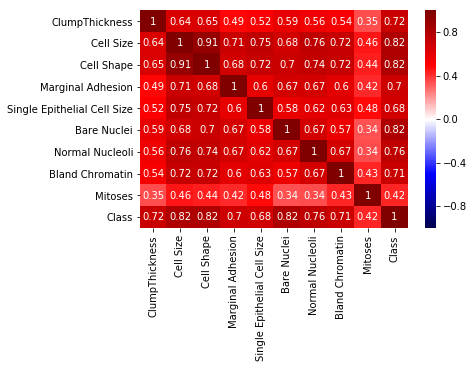

In [10]:
#Let us check for pair plots
sns.heatmap(new_dataset.corr(), annot=True, vmin=-1, vmax=1, cmap='seismic')

# Q5 Remove any unwanted columns or outliers, standardize variables in this pre-processing step

In [11]:
# We could see most of the outliers are now removed.

In [12]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


In [13]:
X = new_dataset

X_std = StandardScaler().fit_transform(X)

C:\Users\selvm\AppData\Local\Continuum\anaconda3\lib\site-packages\sklearn\preprocessing\data.py:625: DataConversionWarning: Data with input dtype int32, int64 were all converted to float64 by StandardScaler.
  return self.partial_fit(X, y)
C:\Users\selvm\AppData\Local\Continuum\anaconda3\lib\site-packages\sklearn\base.py:462: DataConversionWarning: Data with input dtype int32, int64 were all converted to float64 by StandardScaler.
  return self.fit(X, **fit_params).transform(X)


In [14]:
X_std

array([[ 0.20693572, -0.69999505, -0.74329904, ..., -0.61182504,
        -0.34391178, -0.72539705],
       [ 0.20693572,  0.28384518,  0.2668747 , ..., -0.28411186,
        -0.34391178, -0.72539705],
       [-0.50386559, -0.69999505, -0.74329904, ..., -0.61182504,
        -0.34391178, -0.72539705],
       ...,
       [ 0.20693572,  2.25152563,  2.28722218, ...,  2.33759359,
         0.23956962,  1.37855538],
       [-0.14846494,  1.59563215,  0.94032386, ...,  1.02674087,
        -0.34391178,  1.37855538],
       [-0.14846494,  1.59563215,  1.61377302, ...,  0.37131451,
        -0.34391178,  1.37855538]])

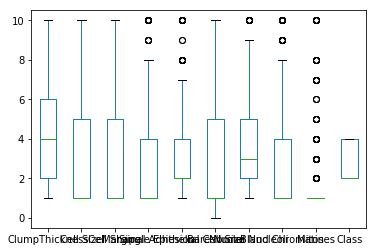

In [22]:
new_dataset.plot.box()
# No outliers are present.

# Q6 Create a covariance matrix for identifying Principal components

In [15]:
# PCA
# Step 1 - Create covariance matrix


In [16]:
cov_matrix = np.cov(X_std.T)
print('Covariance Matrix \n%s', cov_matrix)

Covariance Matrix 
%s [[1.00143266 0.64583645 0.65552689 0.48705303 0.52256381 0.59014075
  0.5592282  0.53660222 0.35053534 0.71702715]
 [0.64583645 1.00143266 0.90818117 0.70659267 0.75287621 0.68554968
  0.75680368 0.72390044 0.4593503  0.81907552]
 [0.65552689 0.90818117 1.00143266 0.68405782 0.72069948 0.70553814
  0.73700282 0.72047704 0.43953974 0.820107  ]
 [0.48705303 0.70659267 0.68405782 1.00143266 0.60045809 0.66667705
  0.66767051 0.60421681 0.41823111 0.69779849]
 [0.52256381 0.75287621 0.72069948 0.60045809 1.00143266 0.58373939
  0.61698451 0.62978166 0.47978787 0.68376273]
 [0.59014075 0.68554968 0.70553814 0.66667705 0.58373939 1.00143266
  0.6725067  0.57287403 0.34328587 0.81882428]
 [0.5592282  0.75680368 0.73700282 0.66767051 0.61698451 0.6725067
  1.00143266 0.66683179 0.34466258 0.75770012]
 [0.53660222 0.72390044 0.72047704 0.60421681 0.62978166 0.57287403
  0.66683179 1.00143266 0.42894941 0.71326403]
 [0.35053534 0.4593503  0.43953974 0.41823111 0.47978787 0.

# Q7 Identify eigen values and eigen vector

In [17]:
# Step 2- Get eigen values and eigen vector

In [18]:
e_vals, e_vecs = np.linalg.eig(cov_matrix)
e_vals, e_vecs = np.linalg.eig(cov_matrix)
print('Eigenvectors \n%s' %e_vecs)
print('\nEigenvalues \n%s' %e_vals)


Eigenvectors 
[[-0.28658147 -0.15501609  0.81835387 -0.01871589 -0.16528898 -0.05690274
   0.06130227 -0.24582098  0.34941921 -0.08336457]
 [-0.35584361 -0.01629638 -0.06746362 -0.74121334 -0.00667062 -0.22235224
  -0.13965149  0.44816789  0.15709771  0.15696969]
 [-0.35294825 -0.05481375 -0.01244653  0.64895086 -0.19609783 -0.20197227
  -0.10694632  0.58320255  0.08143159  0.11700368]
 [-0.30976131 -0.00879065 -0.4065055   0.04582125  0.02001881  0.46918576
   0.03222763 -0.09539101  0.63162137 -0.32711574]
 [-0.31179812  0.19811998 -0.15459716  0.06607196 -0.01215089 -0.35647004
  -0.68354554 -0.45464594 -0.10258647 -0.153573  ]
 [-0.31655971 -0.24716359  0.04712575 -0.1076241  -0.40612563  0.54038841
  -0.13179579  0.04170084 -0.57208853 -0.14677974]
 [-0.32379419 -0.1938246  -0.23223605  0.04934864 -0.07861826 -0.00384615
   0.25316138 -0.40702508  0.00578761  0.75181863]
 [-0.31294578  0.05799824 -0.18069646 -0.02969341 -0.11294557 -0.43225632
   0.63024959 -0.10417123 -0.22546612

# Q8 Find variance and cumulative variance by each eigen vector

In [19]:
tot = sum(e_vals)
var_exp = [( i /tot ) * 100 for i in sorted(eig_vals, reverse=True)]
cum_var_exp = np.cumsum(var_exp)
print("Cumulative Variance Explained", cum_var_exp)

NameError: name 'eig_vals' is not defined

In [ ]:
# Ploting 
plt.figure(figsize=(10 , 5))
plt.bar(range(1, e_vals.size + 1), var_exp, alpha = 0.5, align = 'center', label = 'Individual explained variance')
plt.step(range(1, e_vals.size + 1), cum_var_exp, where='mid', label = 'Cumulative explained variance')
plt.ylabel('Explained Variance Ratio')
plt.xlabel('Principal Components')
plt.legend(loc = 'best')
plt.tight_layout()
plt.show()

# Q9 Use PCA command from sklearn and find Principal Components. Transform data to components formed

In [ ]:
x=new_dataset.drop('Class',axis=1)
y=new_dataset['Class']

In [ ]:
X_centered = X - X.mean(axis=0)
pca = PCA()
pca.fit(X_centered)


In [ ]:
X_pca.shape
print(pca.components_)

In [ ]:
pca.explained_variance_

In [ ]:
pca.explained_variance_ratio_

In [ ]:
X_pca = pca.transform(X_centered)


# Q10 Find correlation between components and features

In [ ]:
# Make a set of (eigenvalue, eigenvector) pairs
eig_pairs = [(e_vals[index], e_vecs[:,index]) for index in range(len(e_vals))]

# Sort the (eigenvalue, eigenvector) pairs from highest to lowest with respect to eigenvalue
eig_pairs.sort()

eig_pairs.reverse()
print(eig_pairs)

# Extract the descending ordered eigenvalues and eigenvectors
eigvalues_sorted = [eig_pairs[index][0] for index in range(len(e_vals))]
eigvectors_sorted = [eig_pairs[index][1] for index in range(len(e_vals))]

# Let's confirm our sorting worked, print out eigenvalues
print('Eigenvalues in descending order: \n%s' %eigvalues_sorted)

In [ ]:
# P_reduce represents reduced mathematical space....

P_reduce = np.array(eigvectors_sorted[0:4])   # Reducing from 8 to 4 dimension space

X_std_4D = np.dot(X_std,P_reduce.T)   # projecting original data into principal component dimensions

Proj_data_df = pd.DataFrame(X_std_4D)  # converting array to dataframe for pairplot

In [ ]:
#Let us check it visually
Proj_data_mpg_df = Proj_data_df.join(y)

sns.pairplot(Proj_data_mpg_df, diag_kind='kde') 